# 1 - Carregamento do dataset e tratamentos necessários

In [ ]:
#Importação padrão do dataset e biblioteca pandas
import pandas as pd

#Carregamento do dataset de notícias
df_noticias = pd.read_csv("../../data/news/articles.csv")

#Visualização das informações do dataset
df_noticias.head()

,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


### O Dataset tem 6 colunas, com uma delas sendo a categoria, chamada *category* e 167.053 linhas

In [ ]:
#Resumo do dataset e contagem dos objetos não nulos
df_noticias.info()
df_noticias

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167053 entries, 0 to 167052
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   title        167053 non-null  object
 1   text         166288 non-null  object
 2   date         167053 non-null  object
 3   category     167053 non-null  object
 4   subcategory  29635 non-null   object
 5   link         167053 non-null  object
dtypes: object(6)
memory usage: 7.6+ MB


,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...
...,...,...,...,...,...,...
167048,"Em cenário de crise, tucano Beto Richa assume ...",O tucano Beto Richa tinha tudo para começar se...,2015-01-01,poder,NaN,http://www1.folha.uol.com.br/poder/2015/01/156...
167049,Filho supera senador Renan Calheiros e assume ...,O economista Renan Filho (PMDB) assume nesta q...,2015-01-01,poder,NaN,http://www1.folha.uol.com.br/poder/2015/01/156...
167050,"Hoje na TV: Tottenham x Chelsea, Campeonato In...",Destaques da programação desta quinta-feira (1...,2015-01-01,esporte,NaN,http://www1.folha.uol.com.br/esporte/2015/01/1...
167051,Kim Jong-un diz estar aberto a se reunir com p...,"O líder norte-coreano, Kim Jong-un, disse nest...",2015-01-01,mundo,NaN,http://www1.folha.uol.com.br/mundo/2015/01/156...


### Valores nulos existentes:

- Título da notícia: 0
- Texto da notícia: 765
- Data da notícia: 0
- Categoria da notícia: 0
- Subcategoria da notícia: 137418
- Link da notícia: 0

In [ ]:
#Soma dos valores faltantes no dataset
df_noticias.isnull().sum()

title               0
text              765
date                0
category            0
subcategory    137418
link                0
dtype: int64

In [4]:
print(df_noticias.dtypes)

title          object
text           object
date           object
category       object
subcategory    object
link           object
dtype: object


In [ ]:
#Contagem dos valores das categorias presentes no dataset
df_noticias['category'].value_counts()

category
poder                           22022
colunas                         21622
mercado                         20970
esporte                         19730
mundo                           17130
cotidiano                       16967
ilustrada                       16345
opiniao                          4525
paineldoleitor                   4011
saopaulo                         3955
tec                              2260
tv                               2142
educacao                         2118
turismo                          1903
ilustrissima                     1411
ciencia                          1335
equilibrioesaude                 1312
sobretudo                        1057
bbc                               980
folhinha                          876
empreendedorsocial                841
comida                            828
asmais                            548
ambiente                          491
seminariosfolha                   379
serafina                          334
o-m

### Nota-se um desbalanceamento após a 7° caregoria, então a análise não conterá todas as 48 categorias, apenas as 7 mais abrangentes

In [6]:
#Categorias com mais notícias
top_categories = [
    "poder",
    "colunas",
    "mercado",
    "esporte",
    "mundo",
    "cotidiano",
    "ilustrada"
]


In [ ]:
#Surgimento da cópia do novo dataset, agora com as categorias filtradas
df_noticias_filtrado = df_noticias[df_noticias["category"].isin(top_categories)].copy()

df_noticias_filtrado["category"].value_counts()


category
poder        22022
colunas      21622
mercado      20970
esporte      19730
mundo        17130
cotidiano    16967
ilustrada    16345
Name: count, dtype: int64

### Os dados foram mantidos com o tipo object, pois todos eram textuais/strings

In [9]:
df_noticias_filtrado.columns

Index(['title', 'text', 'date', 'category', 'subcategory', 'link'], dtype='object')

### Antes de tudo, preencheremos com string vazia os valores em **text** que não possuem informação

In [12]:
df_noticias_filtrado.isnull().sum()

title               0
text              731
date                0
category            0
subcategory    109331
link                0
dtype: int64

In [ ]:
#Preenchimento com string vazia os valores nulos, para que não haja valores faltantes
df_noticias_filtrado["text"] = df_noticias_filtrado["text"].fillna("")
df_noticias_filtrado["title"] = df_noticias_filtrado["title"].fillna("")
df_noticias_filtrado["subcategory"] = df_noticias_filtrado["subcategory"].fillna("desconhecida")


In [ ]:
#Concatenação das colunas titulo + text, que são 2 segmentos complementares, ajudará o modelo no desempenho
df_noticias_filtrado["texto"] = df_noticias_filtrado["title"] + " " + df_noticias_filtrado["text"]


In [16]:
df_noticias_filtrado["texto"].isna().sum()
df_noticias_filtrado.isnull().sum()


title          0
text           0
date           0
category       0
subcategory    0
link           0
texto          0
dtype: int64

### Decidiu-se por utilizar as colunas **title** + **text**, para maior robustez, então unificou-se as colunas em uma única variável chamada **texto**

In [17]:
df_noticias_filtrado

,title,text,date,category,subcategory,link,texto
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,desconhecida,http://www1.folha.uol.com.br/poder/2017/10/192...,"Lula diz que está 'lascado', mas que ainda tem..."
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,desconhecida,http://www1.folha.uol.com.br/ilustrada/2017/10...,"'Decidi ser escrava das mulheres que sofrem', ..."
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,desconhecida,http://www1.folha.uol.com.br/poder/2017/10/192...,Três reportagens da Folha ganham Prêmio Petrob...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,desconhecida,http://www1.folha.uol.com.br/ilustrada/2017/10...,Filme 'Star Wars: Os Últimos Jedi' ganha trail...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,desconhecida,http://www1.folha.uol.com.br/mercado/2017/10/1...,CBSS inicia acordos com fintechs e quer 30% do...
...,...,...,...,...,...,...,...
167048,"Em cenário de crise, tucano Beto Richa assume ...",O tucano Beto Richa tinha tudo para começar se...,2015-01-01,poder,desconhecida,http://www1.folha.uol.com.br/poder/2015/01/156...,"Em cenário de crise, tucano Beto Richa assume ..."
167049,Filho supera senador Renan Calheiros e assume ...,O economista Renan Filho (PMDB) assume nesta q...,2015-01-01,poder,desconhecida,http://www1.folha.uol.com.br/poder/2015/01/156...,Filho supera senador Renan Calheiros e assume ...
167050,"Hoje na TV: Tottenham x Chelsea, Campeonato In...",Destaques da programação desta quinta-feira (1...,2015-01-01,esporte,desconhecida,http://www1.folha.uol.com.br/esporte/2015/01/1...,"Hoje na TV: Tottenham x Chelsea, Campeonato In..."
167051,Kim Jong-un diz estar aberto a se reunir com p...,"O líder norte-coreano, Kim Jong-un, disse nest...",2015-01-01,mundo,desconhecida,http://www1.folha.uol.com.br/mundo/2015/01/156...,Kim Jong-un diz estar aberto a se reunir com p...


### Para visualizar se essa unificação funcionou

In [22]:
df_noticias_filtrado[["title", "text", "texto"]].head()


,title,text,texto
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,"Lula diz que está 'lascado', mas que ainda tem..."
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...","'Decidi ser escrava das mulheres que sofrem', ..."
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,Três reportagens da Folha ganham Prêmio Petrob...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,Filme 'Star Wars: Os Últimos Jedi' ganha trail...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",CBSS inicia acordos com fintechs e quer 30% do...


### Agora iremos normalizar o texto, aproveitando-se da função que o Professor deixou no notebook da aula

In [ ]:
#Normalização que foi feita nas informações
import re
def clean_text(text: str) -> str:
    # Garantir que é string
    text = str(text)
    # Lowercase
    text = text.lower()
    # Remover URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)
    # Remover números
    text = re.sub(r'\d+', ' NUM ', text)
    # Remover pontuação básica
    text = re.sub(r'[\.,;:!\?"\'\(\)\-_/]', ' ', text)
    # Remover múltiplos espaços
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_noticias_filtrado["texto"] = df_noticias_filtrado["texto"].apply(clean_text)

In [25]:
df_noticias_filtrado["texto"]

0         lula diz que está lascado mas que ainda tem fo...
1         decidi ser escrava das mulheres que sofrem diz...
2         três reportagens da folha ganham prêmio petrob...
3         filme star wars os últimos jedi ganha trailer ...
4         cbss inicia acordos com fintechs e quer NUM % ...
                                ...                        
167048    em cenário de crise tucano beto richa assume s...
167049    filho supera senador renan calheiros e assume ...
167050    hoje na tv tottenham x chelsea campeonato ingl...
167051    kim jong un diz estar aberto a se reunir com p...
167052    heitor maia neto NUM NUM pioneiro da arquitetu...
Name: texto, Length: 134786, dtype: object

### O que foi feito até agora?

#### Dataset escolhido - Notícias da Folha de São Paulo - Kaggle.
#### Textos em português.
#### Coluna alvo para classificar - category.
#### Colunas ['title', 'text', 'date', 'category', 'subcategory', 'link'], ignoradas colunas não utilizadas, tratados valores nulos nas relevantes.
#### 48 categorias em **"category"**, notou-se alto desbalanceamento com categorias pouquíssimo presentes, então manteve-se as 7 mais balanceadas. 
#### Criação de uma coluna unificada de texto para aproveitar-se melhor da manchete + corpo da notícia
#### Aplicação da função de normalização disponibilizada pelo Prof. Renan no notebook, com lowercase removendo urls, numeros, pontuação básica e normalizando espaços (acentuação mantida).



# 2 - Divisão em conjunto de treino e teste

In [ ]:
#Importação da biblioteca de separação 
from sklearn.model_selection import train_test_split

X = df_noticias_filtrado["texto"] #É o que será recebido como entrada
y = df_noticias_filtrado["category"] #É o alvo que será predito

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #20% do conjunto para teste
    random_state=42, #Garantia da separação dos dados de maneira pseudoaleatória
    stratify=y  #Mantendo a proporção das categorias, mesmo elas tendo quantidade parecida
)


## Representação com Bag of Words

#### Criação de um baseline simples, qual desempenho obteríamos com unigramas, sem filtros e usando classificador simples

In [ ]:
#Teste simples com o Bag of Words
from sklearn.feature_extraction.text import CountVectorizer

#Código que quebra o texto em palavras e conta quantas vezes ela aparece, transformando-os em representações numéricas
vectorizer_bow = CountVectorizer()
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)


#### Treinamento do classificador usando o Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

#Treinamento com o Naive Bayes
model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


#### Avaliação das métricas após o treinamento com esse teste simples

In [36]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_bow = model_bow.predict(X_test_bow)

print("Accuracy (BoW):", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))


Accuracy (BoW): 0.8250612063209437
              precision    recall  f1-score   support

     colunas       0.76      0.52      0.62      4325
   cotidiano       0.82      0.86      0.84      3393
     esporte       0.94      0.93      0.93      3946
   ilustrada       0.82      0.92      0.86      3269
     mercado       0.78      0.82      0.80      4194
       mundo       0.88      0.91      0.90      3426
       poder       0.79      0.87      0.83      4405

    accuracy                           0.83     26958
   macro avg       0.83      0.83      0.83     26958
weighted avg       0.82      0.83      0.82     26958



# Representação com TF-IDF

#### Vetorização com TF-IDF, semelhante ao Bag of Words, mas com suas particularidades de pesar as palavras

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)


#### Treinamento do classificador usando o Naive Bayes

In [40]:
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


#### Avaliação das métricas após o treinamento

In [41]:
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("Accuracy (TF-IDF):", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))


Accuracy (TF-IDF): 0.8049929519994065
              precision    recall  f1-score   support

     colunas       0.60      0.62      0.61      4325
   cotidiano       0.89      0.74      0.81      3393
     esporte       0.94      0.92      0.93      3946
   ilustrada       0.92      0.76      0.84      3269
     mercado       0.77      0.83      0.80      4194
       mundo       0.92      0.84      0.88      3426
       poder       0.74      0.91      0.82      4405

    accuracy                           0.80     26958
   macro avg       0.83      0.80      0.81     26958
weighted avg       0.81      0.80      0.81     26958



#### Até o momento, foi treinado com as duas representações pedidas, utilizando o Classificador Naive Bayes, obtivemos a criação do Bag of Words e do TF-IDF e o teste com Naive Bayes

#### Agora será feito treinamento com diferentes classificadores e depois a comparação dos resultados

In [55]:
#Todos os imports necessários para rodar o treinamento e as métricas

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Vetorização com Bag of Words, com os hiperparâmetros da descrição do trabalho, utilizando unigramas
bow_vectorizer = CountVectorizer(
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.9
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)


#### Criação de uma função de treino e avaliação

In [ ]:
#Função de treino e avaliação com as métricas principais selecionadas
def treinar_e_avaliar(modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    resultados = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average='macro'),
        "recall_macro": recall_score(y_test, y_pred, average='macro'),
        "f1_macro": f1_score(y_test, y_pred, average='macro'),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

    return resultados


### Agora é rodar os modelos com o Bag of Words e obter o desempenho de cada uma delas

In [ ]:
# Os 5 modelos de classificação escolhidos para o trabalho
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM Linear": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

print("Resultados — Bag of Words\n")

for nome, modelo in modelos.items():
    resultados = treinar_e_avaliar(
        modelo,
        X_train_bow,
        X_test_bow,
        y_train,
        y_test
    )

    print(
        f"{nome}: "
        f"Acc={resultados['accuracy']:.4f} | "
        f"Prec={resultados['precision_macro']:.4f} | "
        f"Rec={resultados['recall_macro']:.4f} | "
        f"F1={resultados['f1_macro']:.4f}"
    )

Resultados — Bag of Words

Naive Bayes: Acc=0.8251 | Prec=0.8253 | Rec=0.8334 | F1=0.8244
Logistic Regression: Acc=0.9110 | Prec=0.9120 | Rec=0.9130 | F1=0.9125
SVM Linear: Acc=0.9078 | Prec=0.9086 | Rec=0.9098 | F1=0.9092
Random Forest: Acc=0.8520 | Prec=0.8547 | Rec=0.8551 | F1=0.8527
KNN: Acc=0.6150 | Prec=0.6856 | Rec=0.6147 | F1=0.6330


# ETAPA COM TF-IDF

#### O processo é parecido, basta alterar algumas partes, treinando com hiperparâmetros, de acordo com a descrição do trabalho

In [ ]:
#TF-IDF com os hiperparâmetros definidos na descrição do trabalho
tfidf = TfidfVectorizer(
    ngram_range=(1,2), #Utilizando bigramas
    min_df=5, #Remoção de palavras que aparecem menos de 5 vezes
    max_df=0.8, #Remoção de palavras que aparecem em mais de 80% dos documentos
    sublinear_tf=True #Aplicação da escala descrita na descrição do trabalho, que ajuda a equilibrar os pesos
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


### Agora é rodar os modelos com o TF-IDF e obter o desempenho de cada uma delas

In [ ]:
# Os 5 Modelos utilizados, novamente os mesmos
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM Linear": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

print("Resultados — TF-IDF\n")

resultados_tfidf = {}

for nome, modelo in modelos.items():
    resultados = treinar_e_avaliar(
        modelo,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test
    )

    resultados_tfidf[nome] = resultados

    print(
        f"{nome}: "
        f"Acc={resultados['accuracy']:.4f} | "
        f"Prec={resultados['precision_macro']:.4f} | "
        f"Rec={resultados['recall_macro']:.4f} | "
        f"F1={resultados['f1_macro']:.4f}"
    )


Resultados — TF-IDF

Naive Bayes: Acc=0.8163 | Prec=0.8316 | Rec=0.8174 | F1=0.8212
Logistic Regression: Acc=0.9165 | Prec=0.9170 | Rec=0.9189 | F1=0.9178
SVM Linear: Acc=0.9362 | Prec=0.9364 | Rec=0.9381 | F1=0.9371
Random Forest: Acc=0.8516 | Prec=0.8544 | Rec=0.8548 | F1=0.8526
KNN: Acc=0.8766 | Prec=0.8784 | Rec=0.8836 | F1=0.8736


#### Tabela comparativa das métricas obtidas
| Representação | Modelo              | Accuracy | Precision | Recall | F1    |
|---------------|---------------------|----------|-----------|--------|-------|
| BoW           | Naive Bayes         | 0.8251   | 0.8253    | 0.8334 | 0.8244|
| TF-IDF        | Naive Bayes         | 0.8163   | 0.8316    | 0.8174 | 0.8212|
| BoW           | Logistic Regression | 0.9110   | 0.9120    | 0.9130 | 0.9125|
| TF-IDF        | Logistic Regression | 0.9165   | 0.9170    | 0.9189 | 0.9178|
| BoW           | SVM Linear          | 0.9078   | 0.9086    | 0.9098 | 0.9092|
|**TF-IDF**        | **SVM Linear**          | **0.9362**   | **0.9364**    | **0.9381** | **0.9371**|
| BoW           | Random Forest       | 0.8520   | 0.8547    | 0.8551 | 0.8527|
| TF-IDF        | Random Forest       | 0.8516   | 0.8544    | 0.8548 | 0.8526|
| BoW           | KNN                 | 0.6150   | 0.6856    | 0.6147 | 0.6330|
| TF-IDF        | KNN                 | 0.8766   | 0.8784    | 0.8836 | 0.8736|


# VISUALIZAÇÃO DOS DADOS - NUVEM DE PALAVRAS

#### Fornecendo uma visualização qualitativa dos termos mais recorrentes nos textos.

##### Nuvem de palavras com o Bag of Words, para visualização das palavras mais comuns no dataset

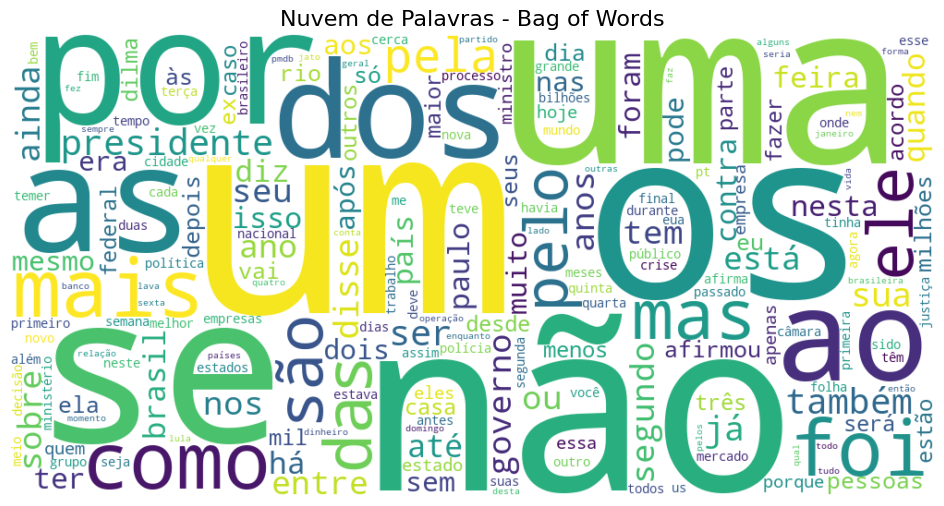

In [62]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Frequências totais das palavras no BoW
freqs_bow = dict(zip(
    bow_vectorizer.get_feature_names_out(),
    X_train_bow.sum(axis=0).A1
))

wc_bow = WordCloud(
    width=1000, height=500,
    background_color="white",
    max_words=200,
    colormap="viridis"
).generate_from_frequencies(freqs_bow)

plt.figure(figsize=(12,6))
plt.imshow(wc_bow, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras - Bag of Words", fontsize=16)
plt.show()


##### Nuvem de palavras com o TF-IDF

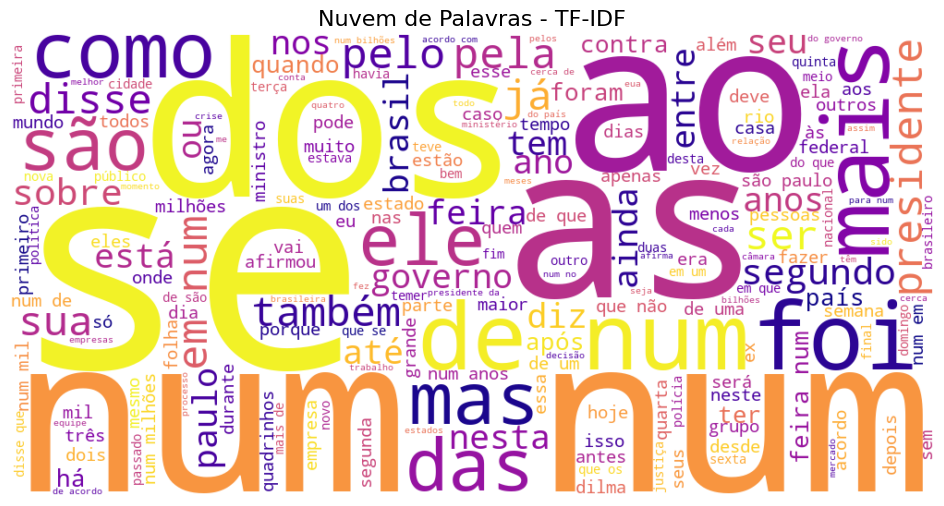

In [63]:
# Frequências ponderadas pelo TF-IDF
freqs_tfidf = dict(zip(
    tfidf.get_feature_names_out(),
    X_train_tfidf.sum(axis=0).A1
))

wc_tfidf = WordCloud(
    width=1000, height=500,
    background_color="white",
    max_words=200,
    colormap="plasma"
).generate_from_frequencies(freqs_tfidf)

plt.figure(figsize=(12,6))
plt.imshow(wc_tfidf, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras - TF-IDF", fontsize=16)
plt.show()


### Matriz de confusão do melhor modelo, SVM Linear com o TF-IDF

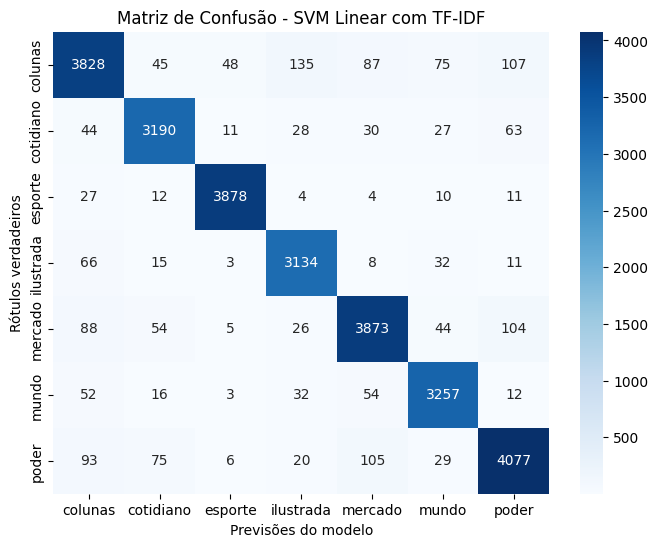

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.svm import LinearSVC
import numpy as np

# Treinar novamente o melhor modelo, pois anteriormente foi tudo treinado de uma vez só dentro do for
svm_best = LinearSVC()
svm_best.fit(X_train_tfidf, y_train)

# Previsões
y_pred_svm_tfidf = svm_best.predict(X_test_tfidf)

# Matriz de confusão absoluta
cm = confusion_matrix(y_test, y_pred_svm_tfidf)

# Plotar matriz absoluta
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.ylabel('Rótulos verdadeiros')
plt.xlabel('Previsões do modelo')
plt.title('Matriz de Confusão - SVM Linear com TF-IDF')
plt.show()
